In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\himan\Desktop\Projects\pathwayIQ\dataset\processed\cleaned_diabetic_data.csv")

df.shape

(101763, 39)

In [4]:
# feature selection
X = df.drop(columns=["target"])
y = df["target"]

In [5]:
X.dtypes.value_counts()

object    27
int64     11
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 27
Numerical: 11


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [11]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'admission_type_id',
                                  'admission_source_id', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses']),
                                ('cat',
                                 Pipeline(s...
                                  'payer_code', 'medical_specialty', 'diag_1',
                                  'diag_2', 'diag_3', 'max_glu_serum',
                                  'A1Cresult', 'metformin', 'repaglinide',
                                  'nateglinide', 'glimepiride', 'glipizide',
                                  'glyburide', 'pioglitazone', 'rosiglitazone',
                                  'acarbose', 'insulin', 'glyburide-metformin',
                                  'glipizide-metformin',
                                  'glimepiride-pioglitazone',
                                  'metformin-rosiglitazone',
                                  'metformin-pioglitazone', 'change',
                                  'diabetesMed'])])

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [13]:
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [14]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'admission_type_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'numbe...
                                                   'max_glu_serum', 'A1Cresult',
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change',
                                                   'diabetesMed'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [15]:
y_pred = model_pipeline.predict(X_test)

y_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8882719992138751
Precision: 0.4788732394366197
Recall: 0.014971378247468076
F1 Score: 0.029035012809564473
ROC-AUC: 0.6784313361641188


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18045    37]
 [ 2237    34]]


In [18]:
y_pred.sum()

np.int64(71)

In [19]:
y_pred_03 = (y_proba >= 0.3).astype(int)

In [20]:
print("Precision:", precision_score(y_test, y_pred_03))
print("Recall:", recall_score(y_test, y_pred_03))
print("F1:", f1_score(y_test, y_pred_03))
print("Predicted Positives:", y_pred_03.sum())

Precision: 0.3604887983706721
Recall: 0.07793923381770146
F1: 0.12816799420709632
Predicted Positives: 491


In [21]:
y_pred_01 = (y_proba >= 0.1).astype(int)

In [22]:
print("Precision:", precision_score(y_test, y_pred_01))
print("Recall:", recall_score(y_test, y_pred_01))
print("F1:", f1_score(y_test, y_pred_01))
print("Predicted Positives:", y_pred_01.sum())

Precision: 0.1671795999120686
Recall: 0.6697490092470277
F1: 0.2675697070982496
Predicted Positives: 9098


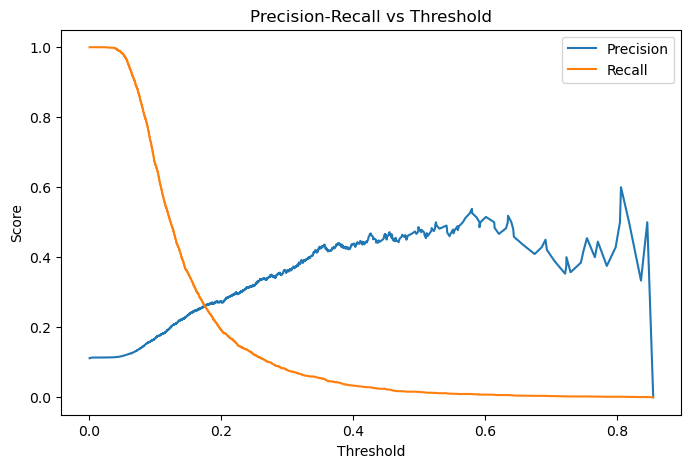

In [23]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()

plt.show()

In [24]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = f1_scores.argmax()

print("Best Threshold:", thresholds[best_idx])
print("Best F1:", f1_scores[best_idx])
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

Best Threshold: 0.13660745081788242
Best F1: 0.2890086807466405
Precision: 0.21896982073973226
Recall: 0.424922941435491


In [25]:
best_threshold = thresholds[best_idx]

y_best = (y_proba >= best_threshold).astype(int)

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_best))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86     18082
           1       0.22      0.42      0.29      2271

    accuracy                           0.77     20353
   macro avg       0.57      0.62      0.57     20353
weighted avg       0.84      0.77      0.80     20353



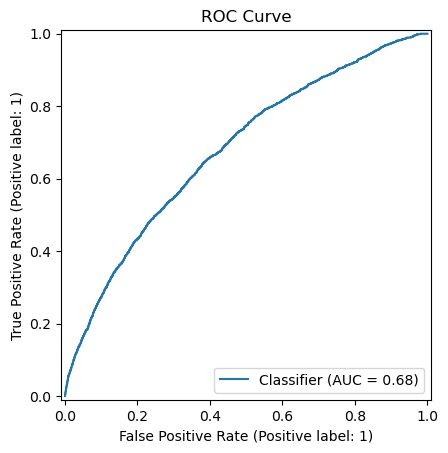

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("ROC Curve")
plt.show()

In [29]:
## Train Logistic Regression with class behaviour
weighted_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [30]:
weighted_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'admission_type_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'numbe...
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change',
                                                   'diabetesMed'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [31]:
y_weighted_pred = weighted_pipeline.predict(X_test)

y_weighted_proba = weighted_pipeline.predict_proba(X_test)[:, 1]

In [32]:
print(classification_report(y_test, y_weighted_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_weighted_proba))

              precision    recall  f1-score   support

           0       0.93      0.68      0.78     18082
           1       0.18      0.58      0.28      2271

    accuracy                           0.66     20353
   macro avg       0.55      0.63      0.53     20353
weighted avg       0.84      0.66      0.73     20353

ROC-AUC: 0.6805915134590885


In [33]:
cm_weighted = confusion_matrix(y_test, y_weighted_pred)

print(cm_weighted)

[[12208  5874]
 [  960  1311]]


In [34]:
y_weighted_pred.sum()

np.int64(7185)

In [36]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [37]:
smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [38]:
smote_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'admission_type_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'numbe...
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change',
                                                   'diabetesMed'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', LogisticRegression(max_iter=1000))])

In [39]:
y_smote_pred = smote_pipeline.predict(X_test)

y_smote_proba = smote_pipeline.predict_proba(X_test)[:, 1]

In [40]:
print(classification_report(y_test, y_smote_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_smote_proba))

              precision    recall  f1-score   support

           0       0.92      0.64      0.76     18082
           1       0.17      0.57      0.26      2271

    accuracy                           0.64     20353
   macro avg       0.55      0.61      0.51     20353
weighted avg       0.84      0.64      0.70     20353

ROC-AUC: 0.6551139091348182


In [41]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline LR (0.5)",
        "Threshold Tuned LR",
        "Class Weighted LR",
        "SMOTE LR"
    ],
    "Precision": [
        0.4789,
        0.2190,
        0.1824,
        0.1670
    ],
    "Recall": [
        0.0150,
        0.4249,
        0.5773,
        0.5720
    ],
    "F1": [
        0.0290,
        0.2890,
        0.2770,
        0.2600
    ],
    "ROC_AUC": [
        0.6784,
        0.6784,
        0.6806,
        0.6551
    ]
})

comparison

,Model,Precision,Recall,F1,ROC_AUC
0,Baseline LR (0.5),0.4789,0.0150,0.029,0.6784
1,Threshold Tuned LR,0.2190,0.4249,0.289,0.6784
2,Class Weighted LR,0.1824,0.5773,0.277,0.6806
3,SMOTE LR,0.1670,0.5720,0.260,0.6551


#### Observations
- default threshold unusable for imbalance
- threshold tuning improved F1 substantially
- class weighting improved recall most effectively
- SMOTE underperformed compared to weighting
- ROC-AUC remained moderate (~0.68)

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [44]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'admission_type_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'numbe...
                                                   'max_glu_serum', 'A1Cresult',
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change',
                                                   'diabetesMed'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [45]:
y_rf_pred = rf_pipeline.predict(X_test)

y_rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [46]:
print(classification_report(y_test, y_rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_rf_proba))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.61      0.01      0.02      2271

    accuracy                           0.89     20353
   macro avg       0.75      0.50      0.48     20353
weighted avg       0.86      0.89      0.84     20353

ROC-AUC: 0.663499834478783


In [47]:
rf_weighted_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [48]:
rf_weighted_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'admission_type_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'numbe...
                                                   'metformin', 'repaglinide',
                                                   'nateglinide', 'glimepiride',
                                                   'glipizide', 'glyburide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change',
                                                   'diabetesMed'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [49]:
y_rf_weighted_pred = rf_weighted_pipeline.predict(X_test)

y_rf_weighted_proba = rf_weighted_pipeline.predict_proba(X_test)[:, 1]

In [50]:
print(classification_report(y_test, y_rf_weighted_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_rf_weighted_proba))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.67      0.01      0.02      2271

    accuracy                           0.89     20353
   macro avg       0.78      0.50      0.48     20353
weighted avg       0.86      0.89      0.84     20353

ROC-AUC: 0.6716078414927721
